# 📞 Emergency Call Triage: ML for Ambulance Dispatch Prioritisation

**Author:** Dean Wang | Lead Data & AI Engineer

**Government:** State Ambulance Services, Triple Zero (000), NHMRC, Dept of Health

Dataset: sklearn synthetic — NO dataset needed.

---

Generated: (2500, 14)


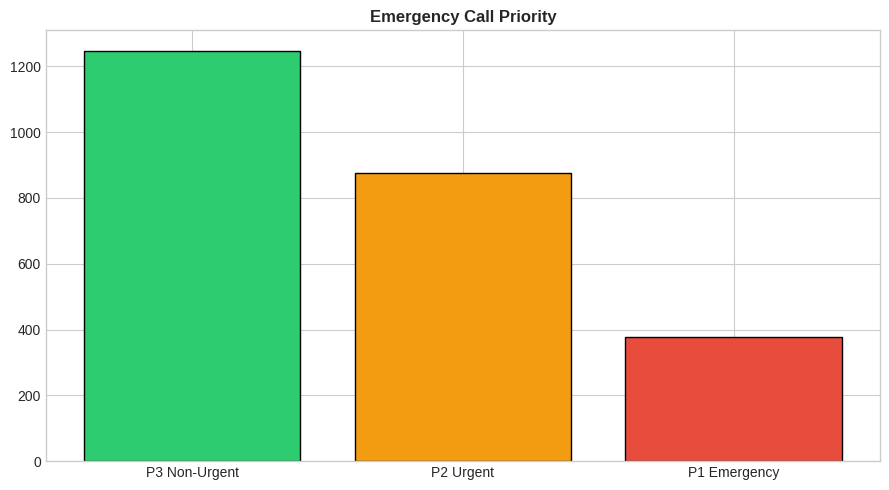

AU: 3.5M+ Triple Zero ambulance calls/year. Response time targets: P1 <15min.
CRITICAL: Model is decision SUPPORT for call-takers — clinical protocols always apply.


In [1]:
import warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,classification_report,cohen_kappa_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
X_arr,y=make_classification(n_samples=2500,n_features=13,n_informative=10,n_classes=3,n_clusters_per_class=1,weights=[0.5,0.35,0.15],random_state=107)
names=['caller_reported_severity','consciousness_level','breathing_status','chest_pain_flag','age','bleeding_severity','trauma_indicator','cardiac_history','response_time_estimate','location_remoteness','time_of_day','prior_calls_24h','vital_signs_score']
df=pd.DataFrame(X_arr,columns=names);df['priority']=y;tc='priority'
tl=['P3 Non-Urgent','P2 Urgent','P1 Emergency'];nc=3
print(f"Generated: {df.shape}");colors=['#2ecc71','#f39c12','#e74c3c']
fig,ax=plt.subplots(figsize=(9,5));vc=df[tc].value_counts().sort_index()
ax.bar(range(nc),vc.values,color=colors,edgecolor='black');ax.set_xticks(range(nc));ax.set_xticklabels(tl)
ax.set_title('Emergency Call Priority',fontweight='bold');plt.tight_layout();plt.savefig('t.png',dpi=150);plt.show()
print("AU: 3.5M+ Triple Zero ambulance calls/year. Response time targets: P1 <15min.")
print("CRITICAL: Model is decision SUPPORT for call-takers — clinical protocols always apply.")

LogReg: Acc=0.9188 F1=0.9183 Kappa=0.8652
RF: Acc=0.9472 F1=0.9465 Kappa=0.9120
XGB: Acc=0.9588 F1=0.9585 Kappa=0.9316
LGBM: Acc=0.9564 F1=0.9561 Kappa=0.9275
Best: XGB


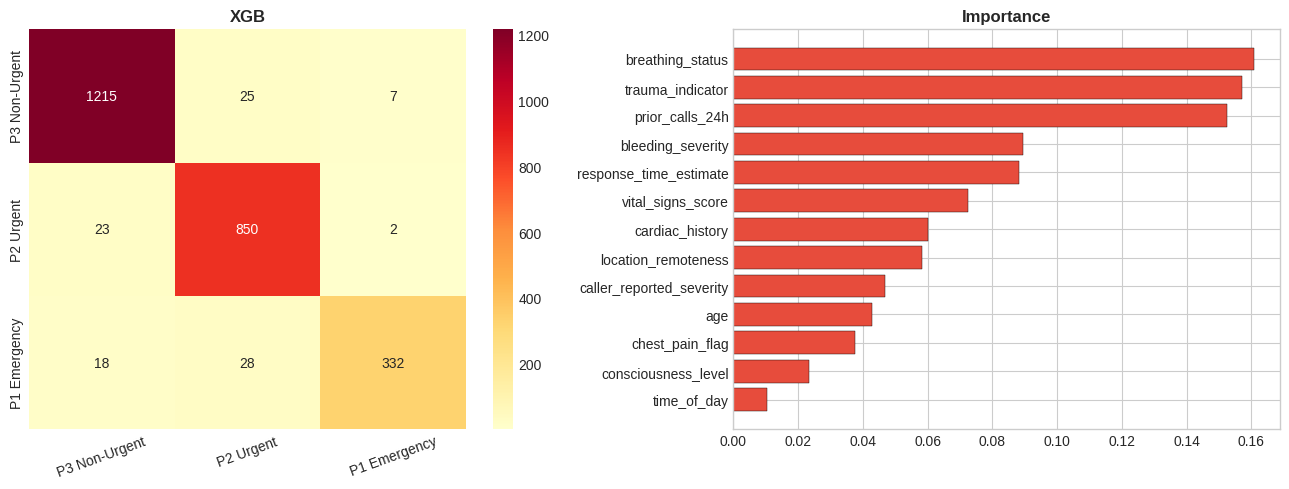

               precision    recall  f1-score   support

P3 Non-Urgent       0.97      0.97      0.97      1247
    P2 Urgent       0.94      0.97      0.96       875
 P1 Emergency       0.97      0.88      0.92       378

     accuracy                           0.96      2500
    macro avg       0.96      0.94      0.95      2500
 weighted avg       0.96      0.96      0.96      2500

DEPLOYMENT: XGB F1=0.9585 Kappa=0.9316 | CAD system -> dispatch prioritisation
SAFETY: Under-triage (P1 as P3) is life-threatening. 100% sensitivity target for P1.


In [2]:
nums=[c2 for c2 in df.columns if c2!=tc];X=df[nums];y2=df[tc].values
try:
    from xgboost import XGBClassifier
except: XGBClassifier=None
try:
    from lightgbm import LGBMClassifier
except: LGBMClassifier=None
models={'LogReg':LogisticRegression(max_iter=2000,random_state=42,multi_class='multinomial'),'RF':RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBClassifier: models['XGB']=XGBClassifier(n_estimators=100,random_state=42,eval_metric='mlogloss',use_label_encoder=False,verbosity=0,n_jobs=-1)
if LGBMClassifier: models['LGBM']=LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
skf=StratifiedKFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    fa,ff,fk=[],[],[];fp=np.zeros(len(y2),dtype=int)
    for fi,(ti,vi) in enumerate(skf.split(Xa,y2)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y2[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        fa.append(accuracy_score(y2[vi],yp));ff.append(f1_score(y2[vi],yp,average='weighted'));fk.append(cohen_kappa_score(y2[vi],yp))
    results[mn]={'acc':np.mean(fa),'f1':np.mean(ff),'kappa':np.mean(fk),'preds':fp}
    print(f"{mn}: Acc={np.mean(fa):.4f} F1={np.mean(ff):.4f} Kappa={np.mean(fk):.4f}")
best=max(results,key=lambda k:results[k]['f1']);print(f"Best: {best}")
bp=results[best]['preds'];cm=confusion_matrix(y2,bp)
fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='YlOrRd',xticklabels=tl,yticklabels=tl,ax=axes[0]);axes[0].set_title(f'{best}',fontweight='bold');axes[0].tick_params(axis='x',rotation=20)
tm={k:v for k,v in models.items() if k!='LogReg'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['f1']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y2)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    axes[1].barh(fi['Feature'],fi['Imp'],color='#e74c3c',edgecolor='black',linewidth=0.3);axes[1].set_title('Importance',fontweight='bold')
plt.tight_layout();plt.savefig('r.png',dpi=150);plt.show()
print(classification_report(y2,bp,target_names=tl))
br=results[best];print(f"DEPLOYMENT: {best} F1={br['f1']:.4f} Kappa={br['kappa']:.4f} | CAD system -> dispatch prioritisation")
print("SAFETY: Under-triage (P1 as P3) is life-threatening. 100% sensitivity target for P1.")